Clone the EEGEmotions repository into a folder not tracked by git.

In this case you can just clone it into the project root since the directory of that repository (`EEGEmotions-27`) has been added to .gitignore.
```shell
git clone https://github.com/huytungst/EEGEmotions-27.git
```

All of the emotion labels that we will be using:

| Emotion ID | Emotion         |
|------------|-----------------|
| 1          | admiration      |
| 2          | adoration       |
| 3          | aesthetic       |
| 4          | amusement       |
| 5          | anger           |
| 6          | anxiety         |
| 7          | awes            |
| 8          | awkwardness     |
| 9          | boredom         |
| 10         | calmness        |
| 11         | confusion       |
| 12         | craving         |
| 13         | disgust         |
| 14         | empathic pain   |
| 15         | entrancement    |
| 16         | excitement      |
| 17         | fear            |
| 18         | horror          |
| 19         | interest        |
| 20         | joy             |
| 21         | nostalgia       |
| 22         | relief          |
| 23         | romance         |
| 24         | sadness         |
| 25         | satisfaction    |
| 26         | sexual desire   |
| 27         | surprised       |


Define the data directory for future use.

In [1]:
from pathlib import Path

data_dir = Path("./data")

Copy all the data into a directory that we manage so that we can preprocess the data.

In [2]:
import shutil
from pathlib import Path

repo_data_dir = Path("../EEGEmotions-27/eeg_raw")

shutil.copytree(repo_data_dir, data_dir, dirs_exist_ok=True)

WindowsPath('data')

Load the metadata of all the EEG files and the list of usable files created by the data preprocessing notebook.

In [3]:
import json

with open("eeg_metadata.json", "r") as f:
    eeg_files_metadata = json.load(f)

with open("usable_signals.json", "r") as f:
    usable_signal_filenames = json.load(f)

We need to downsample some of the data because about half of the data is 256 Hz and about another half is 128 Hz. We need to downsample 256 Hz data to effectively 128 Hz.

In [5]:
from scipy.signal import decimate
from concurrent.futures import ThreadPoolExecutor
import numpy as np

def downsample_if_large(filename: str):
    try:
        path = data_dir / filename
        metadata = eeg_files_metadata[filename]
        data_length = metadata["length"]
        expected_duration = metadata["expected_duration"]
        expected_length = expected_duration * 128
        relative_difference = (data_length - expected_length) / expected_length
        factor = 2
        if relative_difference > 0.5:
            data = np.loadtxt(path)
            if data.shape[0] == data_length:
                print(f"Downsampling {filename} by {factor}. Length: {data_length}, Expected Length: {expected_length}")
                downsampled_data = decimate(data, factor, axis=0)
                np.savetxt(path, downsampled_data)
            else:
                print(f"Thought {filename} needs downsampling but seems like it has been downsampled. Length In Metadata: {data_length}, Actual: {data.shape[0]}")
        else:
            print(f"{filename} does not need downsampling. Length: {data_length}, Expected Length: {expected_length}")
    except Exception as e:
        print(e)

with ThreadPoolExecutor() as executor:
    executor.map(downsample_if_large, usable_signal_filenames)

1_1.0.txt does not need downsampling. Length: 6149.0, Expected Length: 6208.0
1_2.0.txt does not need downsampling. Length: 4099.0, Expected Length: 4160.0
1_3.0.txt does not need downsampling. Length: 3459.0, Expected Length: 3520.0
1_4.0.txt does not need downsampling. Length: 10759.0, Expected Length: 10768.0
1_5.0.txt does not need downsampling. Length: 5893.0, Expected Length: 6010.666624
1_6.0.txt does not need downsampling. Length: 8069.0, Expected Length: 8149.3333760000005
1_7.0.txt does not need downsampling. Length: 8838.0, Expected Length: 8874.666624
1_8.0.txt does not need downsampling. Length: 4483.0, Expected Length: 4512.0
1_9.0.txt does not need downsampling. Length: 4868.0, Expected Length: 4981.333376
1_10.0.txt does not need downsampling. Length: 5380.0, Expected Length: 5434.666624
1_11.0.txt does not need downsampling. Length: 5380.0, Expected Length: 5434.666624
1_12.0.txt does not need downsampling. Length: 6405.0, Expected Length: 6453.333376
1_13.0.txt does n

Next step is to define the dataset object that PyTorch will use for training.

In [15]:
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset

emotions = ["admiration", "adoration", "aesthetic", "amusement", "anger", "anxiety", "awes", "awkwardness", "boredom",
            "calmness", "confusion", "craving", "disgust", "empathic pain", "entrancement", "excitation", "fear",
            "horror", "interest", "joy", "nostalgia", "relief", "romance", "sadness", "satisfaction", "sexual desire",
            "surprised"]


class EmotionsEegFftDataset(Dataset):
    """
    Assumes that datadir only contains EEG signals.
    """
    def __init__(self,
                 eeg_data_dir: Path,
                 eeg_filenames: list[str],
                 data_metadata: dict,
                 sampling_frequency_hz=128,
                 eeg_signal_samples=15000,
                 channel_count=14,
                 frequency_range=(0.5, 45)):
        self.eeg_data_dir = eeg_data_dir
        self.eeg_data_filenames = eeg_filenames
        self.eeg_data_file_metadata = data_metadata

        self.fs = sampling_frequency_hz # sampling frequency of the EEG
        self.eeg_signal_samples = eeg_signal_samples # FFT will pad or truncate the signal to this size

        self.channel_count = channel_count

        min_frequency_hz, max_frequency_hz = frequency_range
        self.frequencies = torch.fft.rfftfreq(self.eeg_signal_samples, d=1 / self.fs)
        self.band_pass_filter = (self.frequencies >= min_frequency_hz) & (self.frequencies <= max_frequency_hz)
        self.frequencies = self.frequencies[self.band_pass_filter] # The frequencies to consider
        self.frequency_count = len(self.frequencies)

        # Extract 0-indexed emotion ID from format `{Participant_ID}_{Emotion_ID}.0.txt`
        self.emotion_labels = [int(filename.split(".", 1)[0].split("_", 1)[1]) - 1 for filename in self.eeg_data_filenames]

    def __len__(self):
        return len(self.eeg_data_filenames)

    def __getitem__(self, item):
        filename = self.eeg_data_filenames[item]
        path = self.eeg_data_dir / filename

        eeg_signal = torch.from_numpy(np.loadtxt(path))

        mean = eeg_signal.mean(dim=0, keepdim=True)
        std = eeg_signal.std(dim=0, keepdim=True)
        std[std == 0] = 1 # prevent division by zero
        normalized_eeg_signal = (eeg_signal - mean) / std
        eeg_fft_tensor = torch.fft.rfft(normalized_eeg_signal, n = self.eeg_signal_samples, dim = 0)
        eeg_fft_tensor = eeg_fft_tensor[self.band_pass_filter, :]
        eeg_fft_tensor = torch.abs(eeg_fft_tensor).float()
        emotion_label = self.emotion_labels[item]
        return (
            eeg_fft_tensor,
            emotion_label
        )


We can then initialize the dataset object.

In [16]:
dataset = EmotionsEegFftDataset(data_dir, usable_signal_filenames, eeg_files_metadata)

print(f"Given {len(dataset)} EEG signals.")

print(f"FFT length: {len(dataset.frequencies)}")

signal_count_by_emotion = {}
for label in dataset.emotion_labels:
    signal_count_by_emotion[label] = signal_count_by_emotion.get(label, 0) + 1

print(", ".join([f"{emotions[key]}: {value}" for key, value in signal_count_by_emotion.items()]))


Given 2335 EEG signals.
FFT length: 5215
admiration: 86, adoration: 88, aesthetic: 86, amusement: 86, anger: 87, anxiety: 87, awes: 87, awkwardness: 86, boredom: 86, calmness: 88, confusion: 88, craving: 87, disgust: 86, empathic pain: 86, entrancement: 85, excitation: 86, fear: 86, horror: 86, interest: 87, joy: 87, nostalgia: 87, relief: 87, romance: 87, sadness: 87, satisfaction: 87, sexual desire: 87, surprised: 82


Visualize the first 15 samples.

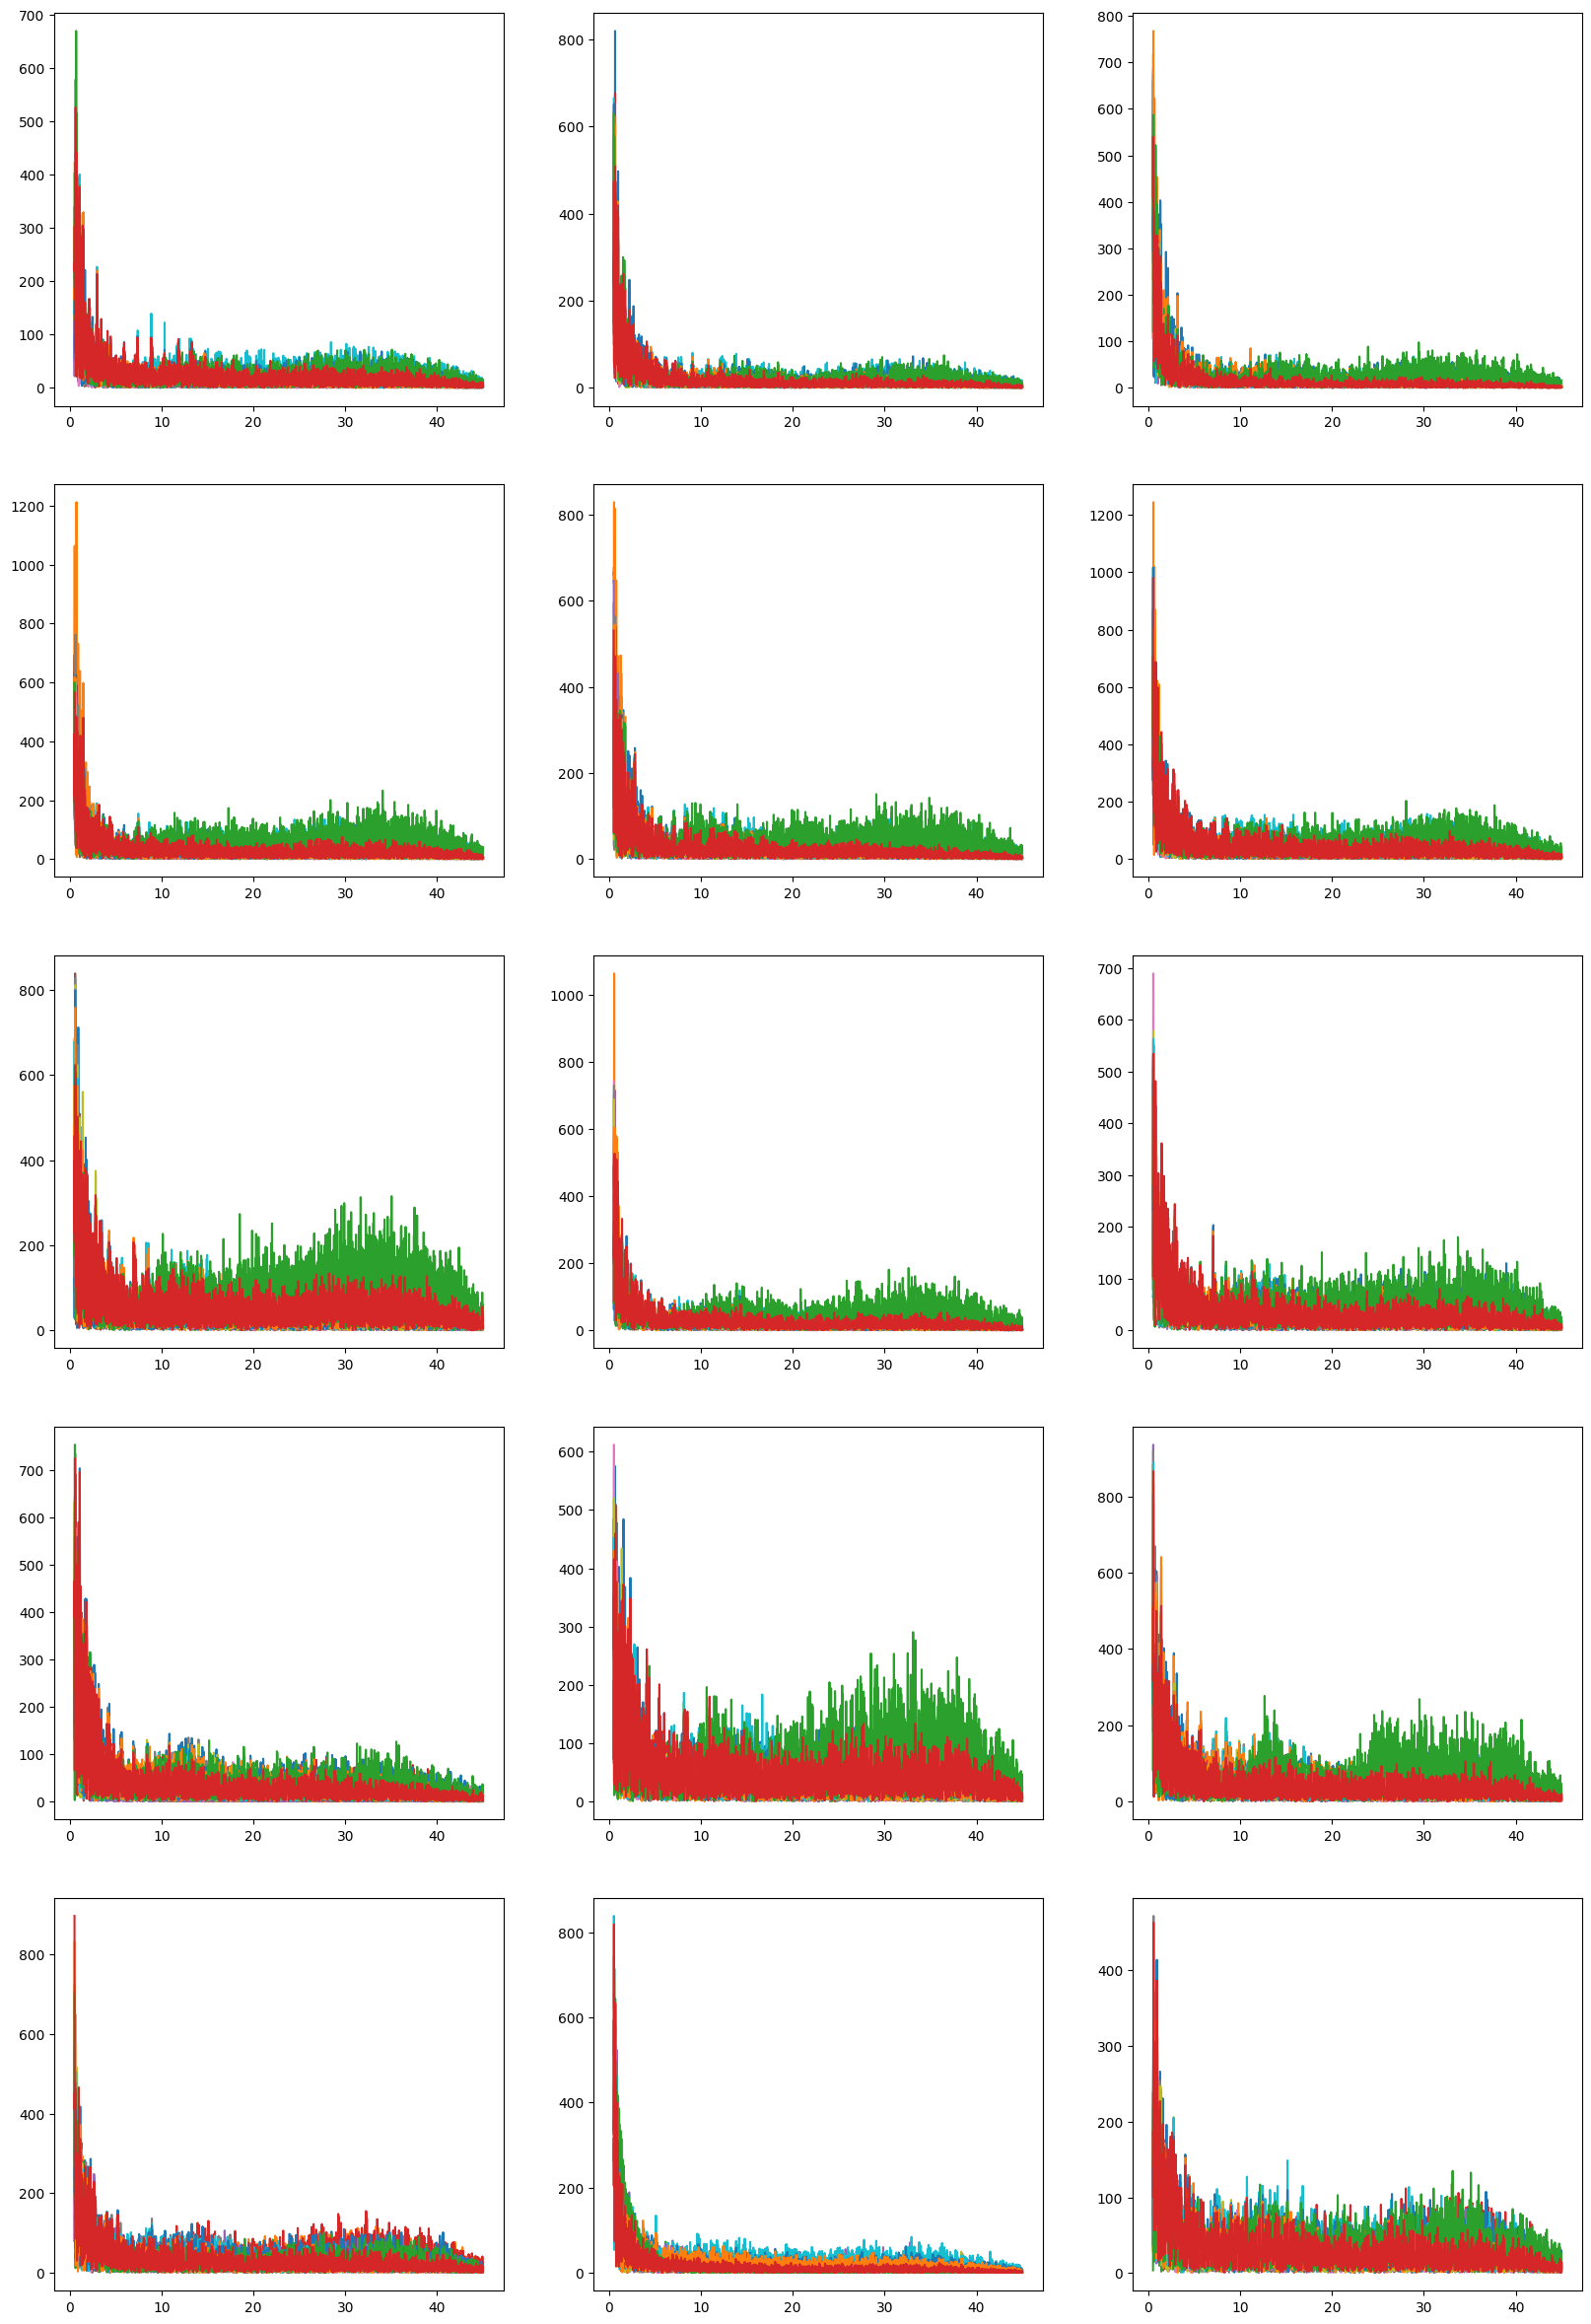

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 30))
for i in range(15):
    fft, label = dataset[i]

    plt.subplot(5, 3, i+1)
    plt.plot(dataset.frequencies, fft)


Define the neural network.

In [18]:
from torch import nn

class EegFftNetwork(nn.Module):
    def __init__(self, frequency_count, channel_count):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(frequency_count * channel_count, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 27),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

Create an instance of the neural network and train the model.

In [ ]:
from torch.utils.data import DataLoader, random_split

seed = 69

dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
test_size = dataset_size - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], torch.manual_seed(seed))

learning_rate = 1e-4
batch_size = 32
epochs = 5

train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EegFftNetwork(dataset.frequency_count, dataset.channel_count).to(device)
print(model)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

def train_loop(dataloader):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        x = X.to(device)
        y = y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(x)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            x = X.to(device)
            y = y.to(device)
            pred = model(x)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(dim=1) == y).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct


epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader)
    test_loop(test_dataloader)
print("Done!")

EegFftNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=73010, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=27, bias=True)
  )
)
Epoch 1
-------------------------------
loss: 7.545308  [   32/ 1868]
